# 01_回归算法-Ridge回归

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/housing.csv`。

转写调整：

- Ridge/Lasso/ElasticNet 比较的标准化统一移入 Pipeline；ElasticNet 的 l1_ratio 不取 0，纯 L2 的情况由 Ridge 演示，避免坐标下降退化。
- 从本地 housing.csv 构造加州房价特征，删除缺失行，固定抽样 2500 行；load_local_housing(sample_size=None) 可运行全量有效数据。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文再和大家一起聊了聊Ridge回归\~

一句话解释Lasso和Ridge的区别和联系：

Lasso回归通过加入 $L1$正则化项，使部分回归系数变为零，实现特征选择。

Ridge回归加入 $L2$正则化项，通过缩小回归系数减小模型复杂度。两者结合可形成弹性网络回归，兼具特征选择和参数缩减。

弹性网络回归咱们下次聊\~

好了，废话不多说，开始上干货！

**Ridge 回归是一种用于处理多重共线性（即自变量之间高度相关）的线性回归技术。它通过在模型中引入一个额外的惩罚项来避免过拟合，从而提高模型的泛化能力。**

那么，具体什么是 Ridge 回归？

**首先来说线性回归**：线性回归是用来预测一个变量（因变量）与一个或多个变量（自变量）之间关系的统计方法。目标是找到一条直线，使得这条直线能最好地拟合数据点。

**多重共线性问题**：在实际应用中，自变量之间有时候会高度相关，这叫做多重共线性。这种情况会导致线性回归模型的预测效果不好，因为模型对训练数据过于敏感（即过拟合），在新数据上表现不佳。

**引入惩罚项**：Ridge 回归通过在损失函数中加入一个惩罚项（也叫正则化项）来解决这个问题。这个惩罚项是所有回归系数的平方和乘以一个常数（惩罚参数）。它的作用是限制回归系数的大小，使得模型不会过度拟合训练数据。

可以说，Ridge 回归是一种增强版的线性回归，通过在损失函数中加入一个惩罚项来限制回归系数的大小，从而减少过拟合并提高模型在新数据上的预测能力。对于咱们大多数同学来说，可以把 Ridge 回归看作是在原有的线性回归基础上“加了一点约束”，使得模型更加稳健。

## 理论基础

刚刚已经说过，Ridge 回归是线性回归的一种变体，通过引入 $L2$ 正则化（惩罚项）来解决多重共线性和防止过拟合问题。

下面，咱们按照一步一步给大家解释清楚：

#### 1. 问题定义

在标准线性回归中，我们有一组样本 $\{(x_i, y_i)\}_{i=1}^{n}$，其中 $x_i \in \mathbb{R}^p$ 是输入特征， $y_i \in \mathbb{R}$ 是目标值。

我们希望找到一组回归系数 $\beta \in \mathbb{R}^p$，使得线性模型 $\hat{y} = X\beta$能最好地拟合数据。

标准线性回归的目标是最小化以下损失函数（均方误差）：


$$
J(\beta) = \sum_{i=1}^n (y_i - x_i^T \beta)^2
$$


#### 2. Ridge 回归的目标函数

Ridge 回归通过在上述目标函数中加入一个正则化项来限制回归系数的大小：


$$
J(\beta) = \sum_{i=1}^n (y_i - x_i^T \beta)^2 + \lambda \sum_{j=1}^p \beta_j^2
$$


其中，$\lambda$ 是正则化参数，控制惩罚项的权重。较大的 $\lambda$ 会更严格地限制 $\beta$ 的大小，防止过拟合。

#### 3. 目标函数的推导

将目标函数展开：


$$
J(\beta) = (y - X\beta)^T(y - X\beta) + \lambda \beta^T \beta
$$


其中， $y$是 $n \times 1$ 的目标值向量， $X$是 $n \times p$ 的输入特征矩阵， $\beta$是 $p \times 1$ 的回归系数向量。

展开并简化：


$$
J(\beta) = y^T y - 2 y^T X \beta + \beta^T X^T X \beta + \lambda \beta^T \beta
$$


#### 4. 梯度计算

为了找到使目标函数最小化的 $\beta$，我们对 $\beta$求导并设置导数为零：


$$
\frac{\partial J(\beta)}{\partial \beta} = -2 X^T y + 2 X^T X \beta + 2 \lambda \beta = 0
$$


简化上式：


$$
X^T X \beta + \lambda \beta = X^T y
$$


#### 5. 解方程

整理上述方程：


$$
(X^T X + \lambda I) \beta = X^T y
$$


其中， $I$是 $p \times p$的单位矩阵。

我们可以通过矩阵求逆来解这个方程：


$$
\beta = (X^T X + \lambda I)^{-1} X^T y
$$


#### 6. 算法流程

1. **准备数据**：获取特征矩阵 $X$ 和目标值向量 $y$。
2. **选择正则化参数**：选择合适的 $\lambda$ 值。
3. **构建矩阵**：计算 $X^T X$ 和 $X^T y$。
4. **添加正则化项**：计算 $X^T X + \lambda I$。
5. **求解回归系数**：通过矩阵求逆计算 $\beta = (X^T X + \lambda I)^{-1} X^T y$。
6. **模型预测**：使用回归系数 $\beta$ 进行预测。

### 例子

假设我们有以下数据：

- 特征矩阵 $X = \begin{bmatrix} 1 & 2 \\ 3 & 4 \\ 5 & 6 \end{bmatrix}$
- 目标值向量 $y = \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}$
- 正则化参数 $\lambda = 1$

计算中间结果：


$$
X^T X = \begin{bmatrix} 35 & 44 \\ 44 & 56 \end{bmatrix}
$$


$$
X^T y = \begin{bmatrix} 22 \\ 28 \end{bmatrix}
$$


$$
\lambda I = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
$$


$$
X^T X + \lambda I = \begin{bmatrix} 36 & 44 \\ 44 & 57 \end{bmatrix}
$$


求解回归系数：


$$
\beta = (X^T X + \lambda I)^{-1} X^T y
$$


这个例子展示了 Ridge 回归的实际计算过程。通过引入正则化项，Ridge 回归能够处理多重共线性问题，并提高模型的泛化能力。

## 完整案例

数据集我们使用加利福尼亚房价数据集。使用 Ridge 回归模型构建、训练、预测、评估和优化。

这里再简单和大家介绍下加利福尼亚房价数据集，在学习阶段，使用频率非常的高\~

加利福尼亚房价数据集（California Housing Dataset）包含了加利福尼亚州各个地区的房价以及相关的地理和人口统计特征。这个数据集是由加利福尼亚州1990年的人口普查数据构建的。

- **数据条目**：20640条记录
- **特征数量**：8个特征
- **目标变量**：房价中位数（`MedHouseVal`）

**特征描述**

1. **`MedInc`**：街区的中位收入
2. **`HouseAge`**：街区中房屋的中位年龄
3. **`AveRooms`**：每户平均房间数
4. **`AveBedrms`**：每户平均卧室数
5. **`Population`**：街区的人口总数
6. **`AveOccup`**：每户平均居住人数
7. **`Latitude`**：街区的纬度
8. **`Longitude`**：街区的经度

**目标变量**

- **`MedHouseVal`**：街区房价的中位数（以美元计）

大家可以使用 `load_local_housing` 函数从 `sklearn.datasets` 模块中加载该数据集。

最佳正则化参数: 78.47599703514607
训练集均方误差: 0.516729195242304
测试集均方误差: 0.5117826838562743
训练集 R^2 分数: 0.6248172656362134
测试集 R^2 分数: 0.592872684428204


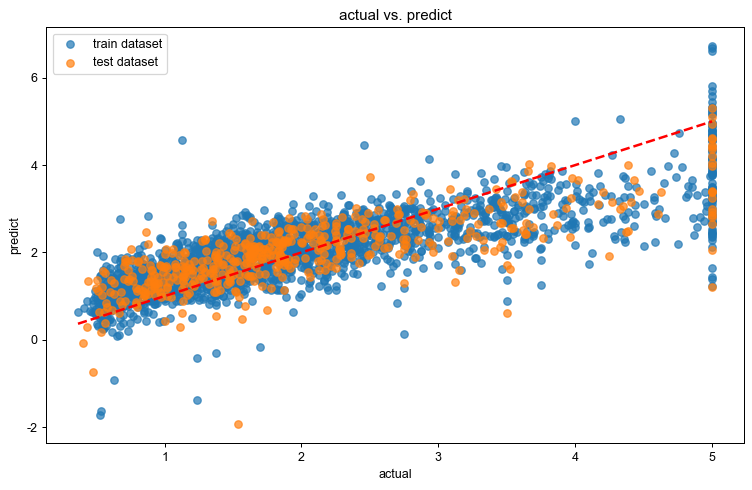

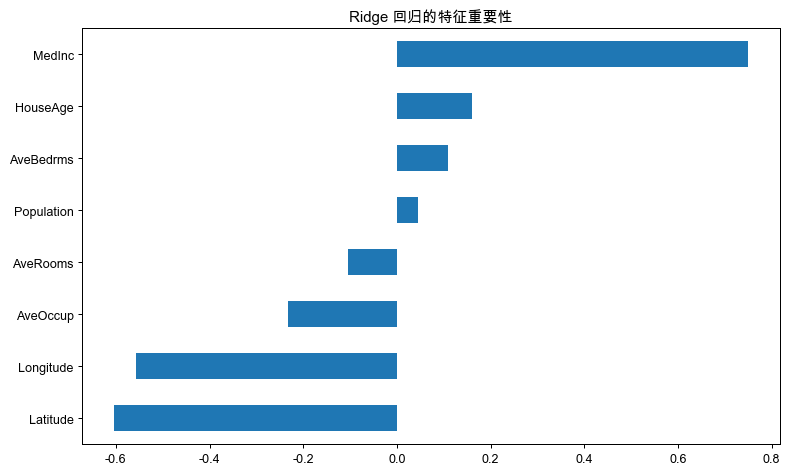

Ridge 回归 - 测试集均方误差: 0.5117826838562743, R^2 分数: 0.592872684428204
Lasso 回归 - 测试集均方误差: 0.5037387862550702, R^2 分数: 0.599271670834771
ElasticNet 回归 - 测试集均方误差: 0.5037387862550702, R^2 分数: 0.599271670834771


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from notebook_support import load_local_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 福尼亚房价数据集
california = load_local_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

# 数据标准化
# 缩放将在每个交叉验证训练折内拟合。

# 为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 正则化参数的候选值
alphas = np.logspace(-4, 4, 20)

# 通过网格搜索和交叉验证来选择最佳正则化参数
ridge = Pipeline([('scale', StandardScaler()), ('model', Ridge())])
grid_search = GridSearchCV(estimator=ridge, param_grid={'model__alpha': alphas}, cv=5, scoring='neg_mean_squared_error', error_score='raise')
grid_search.fit(X_train, y_train)

# 获取最佳模型
best_ridge = grid_search.best_estimator_
print(f"最佳正则化参数: {grid_search.best_params_['model__alpha']}")

# 预测训练集和测试集
y_train_pred = best_ridge.predict(X_train)
y_test_pred = best_ridge.predict(X_test)

# 计算均方误差和R^2分数
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"训练集均方误差: {train_mse}")
print(f"测试集均方误差: {test_mse}")
print(f"训练集 R^2 分数: {train_r2}")
print(f"测试集 R^2 分数: {test_r2}")

# 绘制实际值与预测值对比图
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, label='train dataset', alpha=0.7)
plt.scatter(y_test, y_test_pred, label='test dataset', alpha=0.7)
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--', lw=2)
plt.xlabel('actual')
plt.ylabel('predict')
plt.title('actual vs. predict')
plt.legend()
plt.show()

# 分析特征的重要性
coefs = pd.Series(best_ridge.named_steps['model'].coef_, index=california.feature_names)
coefs.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Ridge 回归的特征重要性')
plt.show()

# 比较其他回归模型

# Lasso 回归
grid_search_lasso = GridSearchCV(estimator=Pipeline([('scale', StandardScaler()), ('model', Lasso(max_iter=10000))]), param_grid={'model__alpha': alphas}, cv=5, scoring='neg_mean_squared_error', error_score='raise')
grid_search_lasso.fit(X_train, y_train)
best_lasso = grid_search_lasso.best_estimator_

# ElasticNet 回归
param_grid = {'model__alpha': alphas, 'model__l1_ratio': np.linspace(0.1, 1, 4)}
grid_search_en = GridSearchCV(estimator=Pipeline([('scale', StandardScaler()), ('model', ElasticNet(max_iter=10000))]), param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', error_score='raise')
grid_search_en.fit(X_train, y_train)
best_elasticnet = grid_search_en.best_estimator_

# 评估所有模型
models = {'Ridge': best_ridge, 'Lasso': best_lasso, 'ElasticNet': best_elasticnet}
for name, model in models.items():
    y_test_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    print(f"{name} 回归 - 测试集均方误差: {mse}, R^2 分数: {r2}")

![原文参考图，当前结果见代码输出](attachments/img_026.png)

整个代码，偏向于实战，包括数据预处理、模型构建、训练、评估和优化。我们还通过与其他回归模型进行比较，评估了 Ridge 回归的性能。通过特征重要性分析，可以进一步理解哪些特征对预测最重要。

这一系列步骤和分析希望可以帮助到大家，在实际应用中更好地理解和使用 Ridge 回归。

## 模型分析

### Ridge 回归模型的优缺点

**优点**：

1. **解决多重共线性问题**：Ridge 回归通过引入 $L2$ 正则化项，可以有效地解决自变量之间存在多重共线性的问题，从而提高模型的稳定性和预测性能。
2. **防止过拟合**：正则化项限制了回归系数的大小，防止模型过拟合训练数据，提升对新数据的泛化能力。
3. **计算效率高**：相比于某些复杂的非线性回归模型，Ridge 回归的计算效率较高，适用于大规模数据集。
4. **参数调整灵活**：通过调整正则化参数 $\lambda$，可以在偏差和方差之间找到最佳平衡，从而优化模型性能。

**缺点**：

1. **不适用于特征选择**：Ridge 回归不会将不相关的特征系数缩减到零，因此不适用于需要进行特征选择的场景。
2. **无法处理非线性关系**：Ridge 回归是线性模型，如果数据中存在复杂的非线性关系，Ridge 回归的表现可能不如非线性模型。
3. **解释性较差**：由于引入了正则化项，Ridge 回归模型的解释性可能较差，不易于解释每个特征对目标值的具体影响。

### 与相似算法的对比

| **对比项** | **Lasso 回归** | **ElasticNet 回归** |
|-|-|-|
| **正则化方式** | 使用 $L1$ 范数（系数的绝对值和） | 结合了 $L1$ 和 $L2$ 范数（系数的绝对值和与平方和） |
| **特征选择** | 能进行特征选择，通过将某些特征的系数缩减为零 | 既能进行特征选择，又能解决多重共线性问题 |
| **优点** | - 可以进行特征选择  <br/>- 产生稀疏模型，适用于高维数据集 | - 结合了 Ridge 和 Lasso 的优点  <br/>- 更加灵活，适应性强 |
| **缺点** | - 对多重共线性不敏感，可能无法选择最优特征  <br/>- 在特征相关性较高时稳定性差 | - 参数选择复杂，需要调节两个正则化参数  <br/>- 计算开销较大 |
| **适用场景** | - 特征数量相对较少  <br/>- 特征不高度相关时 | - 特征数量较多且高度相关时  <br/>- 同时需要特征选择和处理共线性问题 |
| **模型稀疏性** | 由于 $L1$ 正则化，模型会变得更加稀疏 | 结合 $L1$ 和 $L2$ 正则化，可以在两者之间平衡，稀疏性较低 |
| **计算复杂度** | 计算复杂度相对较低，只有一个正则化参数 | 计算复杂度较高，包含两个正则化参数 |
| **调参** | 只需调节一个正则化参数（$\lambda$） | 需要调节两个正则化参数（$\lambda_1$ 和 $\lambda_2$） |

### 使用场景分析

**适合使用 Ridge 回归的场景**

1. **特征之间存在多重共线性**：当特征之间存在高度相关性时，Ridge 回归可以通过 $L2$ 正则化项有效地稳定回归系数，提升模型的稳定性和预测性能。
2. **防止过拟合**：如果数据集较小且存在过拟合的风险，Ridge 回归可以通过限制回归系数的大小，防止模型过拟合。
3. **模型解释性不重要**：在某些情况下，模型的预测性能比解释性更重要，此时可以选择 Ridge 回归。

**考虑其他算法的场景**

1. **需要特征选择**：如果需要选择最相关的特征，Lasso 回归或 ElasticNet 回归更为适合，因为它们可以将不相关特征的系数缩减为零。
2. **存在非线性关系**：如果数据中存在复杂的非线性关系，可以考虑使用决策树、随机森林、支持向量机或神经网络等非线性模型。
3. **高维数据集**：对于特征数量远大于样本数量的高维数据集，Lasso 回归或 ElasticNet 回归可能表现更好，因为它们能够产生更加稀疏的模型。

### 结论

总结一下，Ridge 通过引入 $L2$ 正则化项，可以有效地解决多重共线性问题，并防止过拟合。它在特征之间存在高度相关性、数据集较小且易过拟合的情况下表现良好。

然而，对于需要特征选择或处理非线性关系的场景，可以考虑使用 Lasso 回归、ElasticNet 回归或其他非线性模型。通过结合不同算法的优缺点，实验中大家需要选择最适合特定问题的回归模型，提升模型的预测性能和解释性。